# Odd Vs. Even Classification

Using the MNIST dataset modify the labels in order to have only: 0 -> even, 1 -> odd. 

Then create a Neural Network:  

1. With sequential APIs to classify the data, create a NN with 2 Neuron in the output layers;
2. With sequential APIs to classify the data, creata NN with 1 Neuron in the output layer (using sigmoid and binary crossentropy!);
3. With functional APIs to recreate the previous NNs.

In [74]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras import Sequential
from tensorflow.keras.backend import clear_session
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

## Load the DataSet

In [75]:
(X_train, y_train), (X_test, y_test)  = tf.keras.datasets.mnist.load_data()

## Data Preprocessing
(dataset already explored before)

### Flattening & Standardizing

In [76]:
# flatten the images
X_train_flat = np.reshape(X_train, (60000, 28*28))
X_test_flat = np.reshape(X_test, (10000, 28*28))

# standardize the values
X_train_flat = X_train_flat.astype('float32') / 255
X_test_flat = X_test_flat.astype('float32') / 255

### Labels conversion

In [77]:
# 0 -> even; 1 -> odd
y_train = y_train % 2
y_test = y_test % 2

## Define the NN structure

In [78]:
def get_net():
    model = Sequential()
    model.add(InputLayer(input_shape=(784,)))
    model.add(Dense(500, activation="relu"))
    model.add(Dense(400, activation="relu"))
    model.add(Dense(2, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

### Create the Neural Network

In [79]:
clear_session()
model = get_net()

### Train the Neural Network

In [80]:
history = model.fit(X_train_flat, y_train, epochs=1, verbose=1, batch_size=32, validation_data=(X_test_flat, y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9659 - loss: 0.0950 - val_accuracy: 0.9832 - val_loss: 0.0516


### Analyze training history

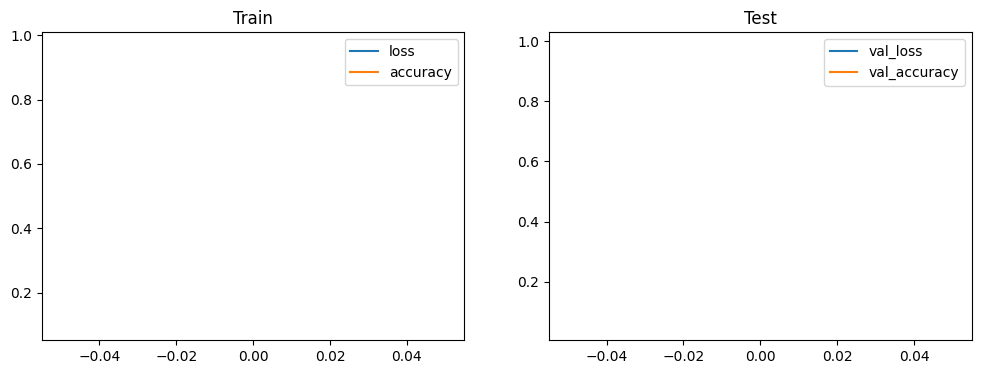

In [81]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.legend()
plt.title("Train")
plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.title("Test");

### Evaluate the Neural Network

In [82]:
model.evaluate(X_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.9832 - loss: 0.0516


[0.05161498859524727, 0.9832000136375427]

## Model with one output Neuron

In [89]:
def get_net_bin():
    model = Sequential()
    model.add(InputLayer(input_shape=(784,)))
    model.add(Dense(500, activation="relu"))
    model.add(Dense(400, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [90]:
clear_session()
model_bin = get_net_bin()

history_bin = model.fit(X_train_flat, y_train, epochs=1, verbose=1, batch_size=32, validation_data=(X_test_flat, y_test))

model_bin.evaluate(X_test_flat, y_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9918 - loss: 0.0271 - val_accuracy: 0.9883 - val_loss: 0.0409
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.4885 - loss: 0.7348


[0.7347986102104187, 0.4884999990463257]